# Three-Ring Filter: S-Parameter vs. Sample-Mode (Delay Artifact Demo)

This notebook builds a triple-ring resonator filter using SiEPIC `half_ring` components and
compares the **exact** S-parameter frequency response against the **sample-mode** time-domain
steady-state.  An `OpticalModulator` is inserted in the bus between ring 1 and ring 2 to serve
as a resonance tuner (voltage-controlled phase shift).

**Key point demonstrated here:** the sample-mode algorithm introduces an artificial one-timestep
delay on every graph edge.  For ring resonators these artificial delays shift the effective
round-trip phase, distorting the steady-state spectrum.  A large `dt` exaggerates this effect.
Delay *compensation* (not applied here) would correct it.

In [8]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

from simphony.circuit.circuit import Circuit
from simphony.simulation.s_parameter import (
    SParameterSimulation,
    SParameterSimulationParameters,
)
from simphony.simulation.sample_mode import (
    SampleModeSimulation,
    SampleModeSimulationParameters,
)
from simphony.libraries.ideal.sources import OpticalCombSource, VoltageSource
from simphony.libraries.ideal.modulators import OpticalModulator
from simphony.libraries.siepic import half_ring, waveguide

## 1. Wavelength Grid

We sweep 101 wavelengths from 1.50–1.60 µm.  The SiEPIC models expect wavelength in **microns**;
the sample-mode simulation stores wavelengths in **metres**.

In [9]:
N_WL = 20001
wl_um = np.linspace(1.50, 1.60, N_WL)   # microns  – used by SiEPIC / S-param
wl_m  = wl_um * 1e-6                     # metres   – used by sample-mode params

## 2. Ring Filter Circuit

**Topology:** three all-pass ring resonators in series on one bus.  Each ring is composed of
one SiEPIC `half_ring` coupler and a closing waveguide.  An `OpticalModulator` sits **inside
each ring cavity** — in the closing-waveguide path between `port_2` and `port_4` — so it
phase-shifts the circulating field and tunes the resonant wavelength.

```
INPUT ──[half_ring_1, port_1→port_3]──[half_ring_2, port_1→port_3]──[half_ring_3, port_1→port_3]── OUTPUT
              coupling ↕                       coupling ↕                    coupling ↕
   port_2 → ring_1_phase_mod → ring_1_closing_wg → port_4   (ring 1 cavity)
   port_2 → ring_2_phase_mod → ring_2_closing_wg → port_4   (ring 2 cavity)
   port_2 → ring_3_phase_mod → ring_3_closing_wg → port_4   (ring 3 cavity)
```

`half_ring` port convention:
- `port_1` / `port_3`: straight bus waveguide (through path)
- `port_2` / `port_4`: ring-arc endpoints — form the ring when connected via the cavity path

**Design procedure:**

1. Evaluate `|S31|` for each `(radius, gap)` from the SiEPIC data.
2. Compute `L_close` for **critical coupling** at `RING_LOSS` dB/cm.
3. Iteratively **tune** `L_close` to place one resonance at the target wavelength.

In [10]:
import pandas as pd

RING_LOSS = 100.0   # dB/cm — waveguide loss in the closing sections

# Fine wavelength grid used only for phase / resonance calculations
_WL_FINE = np.linspace(1.48, 1.62, 400001)   # µm

def _find_resonances(combo, L_close):
    """Return resonant wavelengths (µm) for a given (radius,gap) + L_close."""
    s       = half_ring(wl=_WL_FINE, **combo)
    phi_arc = np.unwrap(np.angle(np.array(s[('port_2', 'port_4')])))
    s_wg    = waveguide(wl=_WL_FINE, width=combo['width'],
                        height=combo['thickness'], length=L_close, loss=0)
    phi_wg  = np.unwrap(np.angle(np.array(s_wg[('o0', 'o1')])))
    phi_rt  = phi_arc + phi_wg
    res = []
    for i in range(len(_WL_FINE) - 1):
        if int(phi_rt[i] / (2*np.pi)) > int(phi_rt[i+1] / (2*np.pi)):
            denom = (phi_rt[i] % (2*np.pi)) - (phi_rt[i+1] % (2*np.pi))
            frac  = np.clip((phi_rt[i] % (2*np.pi)) / max(denom, 1e-12), 0, 1)
            res.append(float(_WL_FINE[i] + frac*(_WL_FINE[i+1] - _WL_FINE[i])))
    return res

def _cc_L_close(combo):
    """Closing-waveguide length for critical coupling at RING_LOSS dB/cm."""
    s   = half_ring(wl=np.array([1.55]), **combo)
    S31 = float(abs(np.array(s[('port_1', 'port_3')])[0]))
    return -20.0 * np.log10(S31) / (RING_LOSS * 1e-4)

def _tune_L_close(combo, L_cc, target_wl, n_iter=4):
    """Iteratively shift the nearest resonance to target_wl."""
    L = L_cc
    for _ in range(n_iter):
        res     = _find_resonances(combo, L)
        if not res:
            break
        nearest = min(res, key=lambda r: abs(r - target_wl))
        C       = np.pi * combo['radius'] + L
        L      += (target_wl - nearest) * C / nearest
    return L

# ── Three rings chosen for minimum inter-ring resonance overlap ──────────────
# Exhaustive search over all valid SiEPIC half_ring combinations showed that
# FSRs of [~24, ~31, ~23] nm (Vernier-like) produce zero coincident resonances
# in the 1.50–1.60 µm band at these three target wavelengths.
_candidates = [
    dict(pol='te', gap=60,  radius=3, width=500, thickness=220, coupling_length=0),  # FSR~24 nm
    dict(pol='te', gap=80,  radius=3, width=500, thickness=220, coupling_length=0),  # FSR~31 nm
    dict(pol='te', gap=100, radius=5, width=500, thickness=220, coupling_length=0),  # FSR~23 nm
]
_targets = [1.52, 1.55, 1.58]   # µm

rows = []
for c, tgt in zip(_candidates, _targets):
    L_cc    = _cc_L_close(c)
    L_tune  = _tune_L_close(c, L_cc, tgt)
    res_all = _find_resonances(c, L_tune)
    res_band = [r for r in res_all if 1.50 <= r <= 1.60]
    nearest  = min(res_band, key=lambda r: abs(r - tgt)) if res_band else None
    C_um     = np.pi * c['radius'] + L_tune
    fsr_nm   = (1.55e-6)**2 / (4.19 * C_um * 1e-6) * 1e9
    rows.append(dict(radius=c['radius'], gap=c['gap'], target_wl=tgt,
                     L_close=L_tune, nearest_res=nearest, fsr_nm=fsr_nm,
                     res_in_band=res_band))

df_design = pd.DataFrame(rows)
print(f"Ring design at RING_LOSS = {RING_LOSS:.0f} dB/cm\n")
for _, row in df_design.iterrows():
    print(f"  r={row.radius:.0f} µm  gap={row.gap:.0f} nm  "
          f"target={row.target_wl:.2f} µm  → nearest res={row.nearest_res:.4f} µm  "
          f"(FSR≈{row.fsr_nm:.1f} nm)")
    print(f"    L_close={row.L_close:.3f} µm   "
          f"all resonances in band: {[f'{r:.4f}' for r in row.res_in_band]}")

Ring design at RING_LOSS = 100 dB/cm

  r=3 µm  gap=60 nm  target=1.52 µm  → nearest res=1.5201 µm  (FSR≈15.0 nm)
    L_close=28.841 µm   all resonances in band: ['1.5057', '1.5201', '1.5347', '1.5496', '1.5648', '1.5803', '1.5961']
  r=3 µm  gap=80 nm  target=1.55 µm  → nearest res=1.5503 µm  (FSR≈20.8 nm)
    L_close=18.095 µm   all resonances in band: ['1.5094', '1.5296', '1.5503', '1.5715', '1.5934']
  r=5 µm  gap=100 nm  target=1.58 µm  → nearest res=1.5800 µm  (FSR≈16.7 nm)
    L_close=18.637 µm   all resonances in band: ['1.5128', '1.5291', '1.5457', '1.5627', '1.5800', '1.5978']


In [11]:
# ── Extract tuned parameters from the design table ───────────────────────────
_c1 = _candidates[0];  _L1 = df_design.iloc[0].L_close
_c2 = _candidates[1];  _L2 = df_design.iloc[1].L_close
_c3 = _candidates[2];  _L3 = df_design.iloc[2].L_close

# Shorthand for the plot / analysis cells below
r1, r2, r3 = _c1['radius'], _c2['radius'], _c3['radius']

def _wg_settings(combo, L_close):
    return dict(length=L_close, width=combo['width'],
                height=combo['thickness'], loss=RING_LOSS)

_mod_settings = dict(
    phase_coefficients     =np.array([0.0, 0.0, 0.0, 0.0]),
    absorption_coefficients=np.array([0.0, 0.0, 0.0, 0.0]),
    length=1.0,
)
_vs_settings = dict(steady_state_voltage=0.0)

# ── Settings that apply to BOTH circuits ─────────────────────────────────────
# (keys must exactly match instance names in sp_circuit)
sp_settings = {
    "half_ring_1":        _c1,
    "half_ring_2":        _c2,
    "half_ring_3":        _c3,
    "ring_1_closing_wg":  _wg_settings(_c1, _L1),
    "ring_2_closing_wg":  _wg_settings(_c2, _L2),
    "ring_3_closing_wg":  _wg_settings(_c3, _L3),
    "ring_1_phase_mod":   _mod_settings,
    "ring_2_phase_mod":   _mod_settings,
    "ring_3_phase_mod":   _mod_settings,
    "ring_1_voltage_src": _vs_settings,
    "ring_2_voltage_src": _vs_settings,
    "ring_3_voltage_src": _vs_settings,
}

# ── Additional settings for the sample-mode circuit only ─────────────────────
# (bus modulators are not in sp_circuit — only added here for sm_circuit)
sm_settings_extra = {
    "bus_mod_1":  _mod_settings,
    "bus_mod_2":  _mod_settings,
    "bus_vs_1":   _vs_settings,
    "bus_vs_2":   _vs_settings,
}

### 2a. S-Parameter Circuit (all-pass rings)

In [12]:
_instances = {
    # Half-ring couplers
    "half_ring_1":        "half_ring",
    "half_ring_2":        "half_ring",
    "half_ring_3":        "half_ring",
    # Closing waveguides — one per ring cavity
    "ring_1_closing_wg":  "waveguide",
    "ring_2_closing_wg":  "waveguide",
    "ring_3_closing_wg":  "waveguide",
    # Phase modulators — inside each ring cavity between port_2 and port_4
    "ring_1_phase_mod":   "modulator",
    "ring_2_phase_mod":   "modulator",
    "ring_3_phase_mod":   "modulator",
    # Voltage sources — one per modulator
    "ring_1_voltage_src": "voltage_source",
    "ring_2_voltage_src": "voltage_source",
    "ring_3_voltage_src": "voltage_source",
}

_connections = {
    # ── Bus path: straight through each half_ring ─────────────────────────────
    "half_ring_1,port_3":        "half_ring_2,port_1",
    "half_ring_2,port_3":        "half_ring_3,port_1",

    # ── Ring cavities: port_2 → phase_mod → closing_wg → port_4 ─────────────
    "half_ring_1,port_2":        "ring_1_phase_mod,o0",
    "ring_1_phase_mod,o1":       "ring_1_closing_wg,o0",
    "ring_1_closing_wg,o1":      "half_ring_1,port_4",

    "half_ring_2,port_2":        "ring_2_phase_mod,o0",
    "ring_2_phase_mod,o1":       "ring_2_closing_wg,o0",
    "ring_2_closing_wg,o1":      "half_ring_2,port_4",

    "half_ring_3,port_2":        "ring_3_phase_mod,o0",
    "ring_3_phase_mod,o1":       "ring_3_closing_wg,o0",
    "ring_3_closing_wg,o1":      "half_ring_3,port_4",

    # ── Electrical bias ───────────────────────────────────────────────────────
    "ring_1_voltage_src,e0":     "ring_1_phase_mod,e0",
    "ring_2_voltage_src,e0":     "ring_2_phase_mod,e0",
    "ring_3_voltage_src,e0":     "ring_3_phase_mod,e0",
}

sp_netlist = {
    "instances":   _instances,
    "connections": _connections,
    "ports": {"in": "half_ring_1,port_1", "out": "half_ring_3,port_3"},
}

_models = {
    "half_ring":      half_ring,
    "waveguide":      waveguide,
    "modulator":      OpticalModulator,
    "voltage_source": VoltageSource,
}

sp_circuit = Circuit(sp_netlist, _models)

### 2b. Sample-Mode Circuit

The S-parameter simulation has the phase modulators **inside each ring cavity** (physically
correct).  In sample mode the simulator consolidates all SAX `SParameterPlaceholder` components
that are weakly connected into a single S-parameter group.  Without any non-SAX component on
the bus, all six passive elements (three half-rings + three closing waveguides) collapse into
one large group, making the initial-state computation extremely slow.

To restore the three compact per-ring groups we add **two transparent bus modulators** (biased
at 0 V → unity transmission) between the rings.  These are for computational efficiency only
and have no effect on the optical response.  The physically accurate result is the S-parameter
simulation above.

In [14]:
import sax
# ── Combined ring-filter: single SAX node, no inter-component edges ───────────
# Build one SAX circuit function that collapses all three rings + closing
# waveguides into a single callable.  Using this as a single Simphony component
# eliminates the inter-component edges that produce artificial one-step delays
# in the sample-mode algorithm.

_rf_netlist = {
    "instances": {
        "half_ring_1":       {"component": "half_ring", "settings": _c1},
        "ring_1_closing_wg": {"component": "waveguide",  "settings": _wg_settings(_c1, _L1)},
        "half_ring_2":       {"component": "half_ring", "settings": _c2},
        "ring_2_closing_wg": {"component": "waveguide",  "settings": _wg_settings(_c2, _L2)},
        "half_ring_3":       {"component": "half_ring", "settings": _c3},
        "ring_3_closing_wg": {"component": "waveguide",  "settings": _wg_settings(_c3, _L3)},
    },
    "connections": {
        "half_ring_1,port_3":   "half_ring_2,port_1",
        "half_ring_2,port_3":   "half_ring_3,port_1",
        "half_ring_1,port_2":   "ring_1_closing_wg,o0",
        "ring_1_closing_wg,o1": "half_ring_1,port_4",
        "half_ring_2,port_2":   "ring_2_closing_wg,o0",
        "ring_2_closing_wg,o1": "half_ring_2,port_4",
        "half_ring_3,port_2":   "ring_3_closing_wg,o0",
        "ring_3_closing_wg,o1": "half_ring_3,port_4",
    },
    "ports": {"in": "half_ring_1,port_1", "out": "half_ring_3,port_3"},
}

_ring_filter_fn, _ = sax.circuit(
    _rf_netlist, {"half_ring": half_ring, "waveguide": waveguide}
)

def ring_filter_combined(*, wl=1.55):
    """Full 3-ring filter collapsed into a single SAX node (no inter-component edges).
    wl is in µm (SAX convention).
    """
    return _ring_filter_fn(wl=wl)


In [15]:
# Sample-mode topology: in-ring phase mods retained; two transparent bus mods
# added between rings to keep each ring as its own 2-component S-param group.
sm_instances = {
    **{k: v for k, v in _instances.items()},   # all instances from sp_circuit
    # Transparent bus modulators — 0 V bias, break S-param group boundary
    "bus_mod_1":  "modulator",
    "bus_vs_1":   "voltage_source",
    "bus_mod_2":  "modulator",
    "bus_vs_2":   "voltage_source",
    "source":     "comb_source",
    # ── Disconnected subcircuit: combined filter with no inter-component edges ──
    "source_2":       "comb_source",
    "ring_filter_2":  "ring_filter_combined",
}

# Rebuild bus path through the two transparent modulators
sm_connections = {
    k: v for k, v in _connections.items()
    if k not in {"half_ring_1,port_3", "half_ring_2,port_3"}   # replaced below
}
sm_connections.update({
    "half_ring_1,port_3": "bus_mod_1,o0",
    "bus_mod_1,o1":       "half_ring_2,port_1",
    "half_ring_2,port_3": "bus_mod_2,o0",
    "bus_mod_2,o1":       "half_ring_3,port_1",
    "bus_vs_1,e0":        "bus_mod_1,e0",
    "bus_vs_2,e0":        "bus_mod_2,e0",
    "source,o0":          "half_ring_1,port_1",
    # ── Subcircuit connections (disconnected from main circuit) ──────────────
    "source_2,o0":        "ring_filter_2,in",
})

sm_netlist = {
    "instances":   sm_instances,
    "connections": sm_connections,
    "ports": {
        "out":        "half_ring_3,port_3",   # main circuit output (with edges)
        "out_noedge": "ring_filter_2,out",    # subcircuit output (no inter-component edges)
    },
}

sm_models  = {**_models, "comb_source": OpticalCombSource, "ring_filter_combined": ring_filter_combined}
sm_circuit = Circuit(sm_netlist, sm_models)


## 3. S-Parameter Simulation (Ground Truth)

In [16]:
sp_params = SParameterSimulationParameters()   # wl is passed in run(), not here

sp_sim    = SParameterSimulation(sp_circuit, sp_settings, sp_params)
sp_result = sp_sim.run(wl=wl_um)   # SiEPIC models expect µm

sp_transmission = np.abs(np.array(sp_result.s_parameters[("in", "out")]))**2
print(f"S-parameter shape: {sp_transmission.shape}")
print(f"Transmission range: [{sp_transmission.min():.4f}, {sp_transmission.max():.4f}]")

for tgt in _targets:
    idx   = np.argmin(np.abs(wl_um - tgt))
    local = sp_transmission[max(0, idx-15):idx+16]
    print(f"  Target {tgt:.2f} µm → min T in ±1.5 nm window = {local.min():.4f}")

/home/wyrgly/projects/camacholab/simphony/.venv/lib/python3.12/site-packages/sax/utils.py:80: UserWarning: Could not validate netlist for 'top_level'. This netlist will be ignored.
  return func(*args, **kwargs)


S-parameter shape: (20001,)
Transmission range: [0.0000, 0.9958]
  Target 1.52 µm → min T in ±1.5 nm window = 0.0315
  Target 1.55 µm → min T in ±1.5 nm window = 0.5907
  Target 1.58 µm → min T in ±1.5 nm window = 0.0051


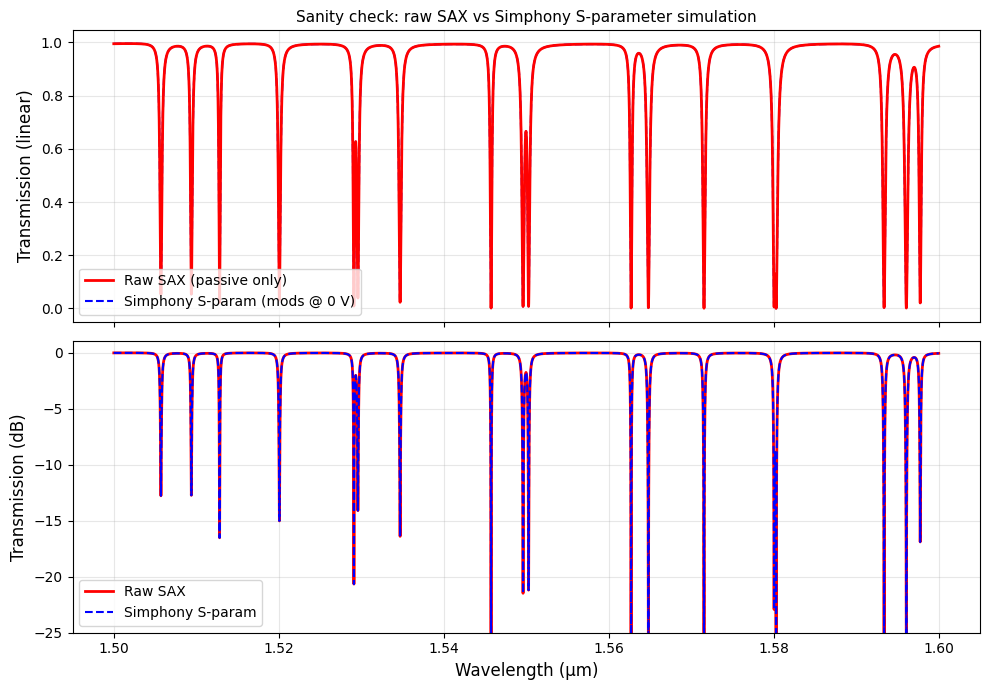

Max |SAX − Simphony| difference: 1.15e-14


In [17]:
# ── TEMPORARY SANITY CHECK: raw SAX vs Simphony S-parameter simulation ──────
import sax

def _sax_wg(c, L):
    return {"component": "waveguide",
            "settings": dict(length=L, width=c['width'],
                             height=c['thickness'], loss=RING_LOSS)}

_sax_netlist = {
    "instances": {
        "half_ring_1":       {"component": "half_ring", "settings": _c1},
        "ring_1_closing_wg": _sax_wg(_c1, _L1),
        "half_ring_2":       {"component": "half_ring", "settings": _c2},
        "ring_2_closing_wg": _sax_wg(_c2, _L2),
        "half_ring_3":       {"component": "half_ring", "settings": _c3},
        "ring_3_closing_wg": _sax_wg(_c3, _L3),
    },
    "connections": {
        # Bus — direct, no modulator
        "half_ring_1,port_3":   "half_ring_2,port_1",
        "half_ring_2,port_3":   "half_ring_3,port_1",
        # Ring cavities — closing wg only (no modulator in SAX check)
        "half_ring_1,port_2":   "ring_1_closing_wg,o0",
        "ring_1_closing_wg,o1": "half_ring_1,port_4",
        "half_ring_2,port_2":   "ring_2_closing_wg,o0",
        "ring_2_closing_wg,o1": "half_ring_2,port_4",
        "half_ring_3,port_2":   "ring_3_closing_wg,o0",
        "ring_3_closing_wg,o1": "half_ring_3,port_4",
    },
    "ports": {"in": "half_ring_1,port_1", "out": "half_ring_3,port_3"},
}

sax_circuit_fn, _ = sax.circuit(
    _sax_netlist, {"half_ring": half_ring, "waveguide": waveguide}
)
sax_result       = sax_circuit_fn(wl=wl_um)
sax_transmission = np.abs(np.array(sax_result[("in", "out")]))**2

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax = axes[0]
ax.plot(wl_um, sax_transmission, 'r-',  lw=2.0, label='Raw SAX (passive only)', zorder=3)
ax.plot(wl_um, sp_transmission,  'b--', lw=1.5, label='Simphony S-param (mods @ 0 V)')
ax.set_ylabel('Transmission (linear)', fontsize=12)
ax.set_title('Sanity check: raw SAX vs Simphony S-parameter simulation', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(wl_um, 10*np.log10(np.clip(sax_transmission, 1e-10, None)),
         'r-', lw=2.0, label='Raw SAX')
ax2.plot(wl_um, 10*np.log10(np.clip(sp_transmission,  1e-10, None)),
         'b--',lw=1.5, label='Simphony S-param')
ax2.set_xlabel('Wavelength (µm)', fontsize=12)
ax2.set_ylabel('Transmission (dB)', fontsize=12)
ax2.set_ylim(-25, 1); ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Max |SAX − Simphony| difference: {np.max(np.abs(sax_transmission - sp_transmission)):.2e}")

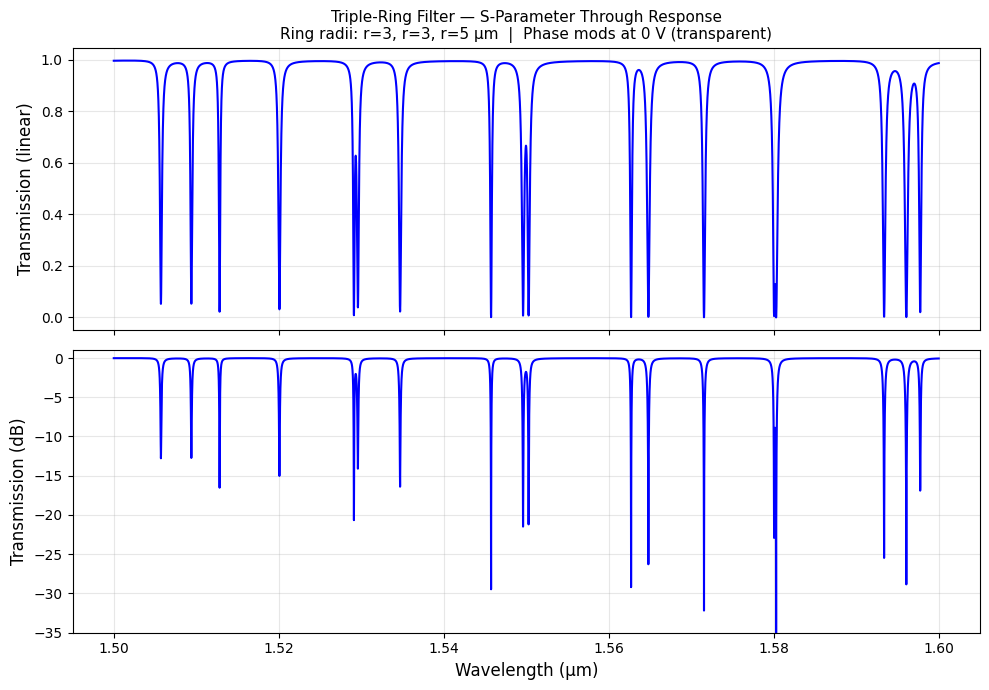

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax = axes[0]
ax.plot(wl_um, sp_transmission, 'b-', lw=1.5)
ax.set_ylabel('Transmission (linear)', fontsize=12)
ax.set_title(
    f'Triple-Ring Filter — S-Parameter Through Response\n'
    f'Ring radii: r={r1}, r={r2}, r={r3} µm  |  Phase mods at 0 V (transparent)',
    fontsize=11
)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
sp_dB = 10 * np.log10(np.clip(sp_transmission, 1e-10, None))
ax2.plot(wl_um, sp_dB, 'b-', lw=1.5)
ax2.set_xlabel('Wavelength (µm)', fontsize=12)
ax2.set_ylabel('Transmission (dB)', fontsize=12)
ax2.set_ylim(-35, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Sample-Mode Simulation

We use a **large `dt`** (500 fs) to exaggerate the delay-compensation problem.  Each
inter-component edge introduces an artificial one-step delay of `dt`.  Because the ring
round-trip times are comparable to (or shorter than) `dt`, the artificial delays
significantly distort the apparent resonance positions.

After the transient settles we time-average the output power at each wavelength to
estimate the steady-state spectrum.

In [29]:
DT = 2e-14
N_STEPS = 10000
TRANSIENT = 5
WG_DELAY_COMP = 3 # This is where I toggle the delay compensation between 3 and 0
HR_DELAY_COMP = 0
PHASE_CORRECTION = True
# PHASE_CORRECTION = False

sm_wl = jnp.linspace(1.5, 1.6, 11)*1e-6   # 11 wavelengths: 1.50, 1.51, ..., 1.60 µm
sm_params = SampleModeSimulationParameters(
    optical_baseband_wavelengths=jnp.array(sm_wl),
    dt=DT,
    num_time_steps=N_STEPS,
)

sm_settings = {
    **sp_settings,       # phase mods, voltage sources (no delay comp needed)
    **sm_settings_extra, # transparent bus mods (sample-mode only)
    # ── Main circuit: half-ring couplers ─────────────────────────────────────
    "half_ring_1": {"sax_settings": _c1, "delay_compensation": HR_DELAY_COMP, "apply_phase_correction": PHASE_CORRECTION, "vector_fitting_parameters": {"model_order": 50}},
    "half_ring_2": {"sax_settings": _c2, "delay_compensation": HR_DELAY_COMP, "apply_phase_correction": PHASE_CORRECTION, "vector_fitting_parameters": {"model_order": 50}},
    "half_ring_3": {"sax_settings": _c3, "delay_compensation": HR_DELAY_COMP, "apply_phase_correction": PHASE_CORRECTION, "vector_fitting_parameters": {"model_order": 50}},
    # ── Main circuit: closing waveguides ─────────────────────────────────────
    "ring_1_closing_wg": {"sax_settings": _wg_settings(_c1, _L1), "delay_compensation": WG_DELAY_COMP,  "apply_phase_correction": PHASE_CORRECTION, "vector_fitting_parameters": {"model_order": 50}},
    "ring_2_closing_wg": {"sax_settings": _wg_settings(_c2, _L2), "delay_compensation": WG_DELAY_COMP,  "apply_phase_correction": PHASE_CORRECTION, "vector_fitting_parameters": {"model_order": 50}},
    "ring_3_closing_wg": {"sax_settings": _wg_settings(_c3, _L3), "delay_compensation": WG_DELAY_COMP,  "apply_phase_correction": PHASE_CORRECTION, "vector_fitting_parameters": {"model_order": 50}},
    # ── Main circuit comb source ──────────────────────────────────────────────
    "source":   {"wavelength": jnp.array(sm_wl), "linewidth": 0.0},
    # ── Subcircuit: combined filter (single node, no inter-component edges) ───
    "source_2":      {"wavelength": jnp.array(sm_wl), "linewidth": 0.0},
    "ring_filter_2": {"sax_settings": {}, "delay_compensation": 0, "apply_phase_correction": False,
                      "vector_fitting_parameters": {"model_order": 100}},
}

tracked_ports = {
    "out":        "half_ring_3,port_3",  # main circuit (with inter-component edges)
    "out_noedge": "ring_filter_2,out",   # subcircuit (single combined S-param node)
}

sm_sim = SampleModeSimulation(
    sm_circuit,
    sm_settings,
    tracked_ports=tracked_ports,
    simulation_parameters=sm_params,
)

print(f"Running sample-mode simulation ({N_STEPS} steps × {len(sm_wl)} wavelengths, "
      f"dt={DT:.0e} s, delay_compensation={WG_DELAY_COMP}) …")
sm_result = sm_sim.run(use_jit=True)
print("Done.")


Running sample-mode simulation (10000 steps × 11 wavelengths, dt=2e-14 s, delay_compensation=3) …


Sigma(nx.MultiDiGraph with 21 nodes and 35 edges)

1.9917542934417725
Done.


In [30]:
# Inspect the new result structure.
# sm_result.output_signals / input_signals are keyed by tracked port name ("out").
print("Tracked output signals:")
for port_name, sig in sm_result.output_signals.items():
    if hasattr(sig, 'amplitude'):
        amp = np.array(sig.amplitude)
        print(f"  {port_name!r}: shape={amp.shape}  max|A|={np.abs(amp).max():.4f}")

print("\nTracked input signals:")
for port_name, sig in sm_result.input_signals.items():
    if hasattr(sig, 'amplitude'):
        amp = np.array(sig.amplitude)
        print(f"  {port_name!r}: shape={amp.shape}  max|A|={np.abs(amp).max():.4f}")

# Quick amplitude-vs-time preview at a handful of wavelengths
out_amp_preview = np.array(sm_result.output_signals["out"].amplitude)  # (T, L, M)
out_noedge_amp_preview = np.array(sm_result.output_signals["out_noedge"].amplitude)  # (T, L, M)
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(0, len(sm_wl), max(1, len(sm_wl) // 6)):
    ax.plot(np.abs(out_amp_preview[:, i, 0]), label=f'{float(sm_wl[i])*1e6:.3f} µm')
    ax.plot(np.abs(out_noedge_amp_preview[:, i, 0]), label=f'{float(sm_wl[i])*1e6:.3f} µm')
ax.set_xlabel('Time step')
ax.set_ylabel('|amplitude|')
ax.set_title('Output amplitude vs time at selected wavelengths')
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Tracked output signals:
  'out': shape=(10000, 11, 2)  max|A|=1.0793
  'out_noedge': shape=(10000, 11, 2)  max|A|=1.0796

Tracked input signals:
  'out': shape=(10000, 11, 2)  max|A|=0.0000
  'out_noedge': shape=(10000, 11, 2)  max|A|=0.0000


In [31]:
# Extract time-series from both tracked output ports.
# Amplitude shape: (N_STEPS, L, M)  where L = wavelengths, M = modes.
out_amp        = np.array(sm_result.output_signals["out"].amplitude)        # main circuit
out_amp_noedge = np.array(sm_result.output_signals["out_noedge"].amplitude) # combined node
sm_wl_um = np.array(sm_wl) * 1e6   # µm — for plotting

print(f"Main circuit  output: shape={out_amp.shape}        max|A|={np.abs(out_amp).max():.4f}")
print(f"No-edge output:       shape={out_amp_noedge.shape}  max|A|={np.abs(out_amp_noedge).max():.4f}")


Main circuit  output: shape=(10000, 11, 2)        max|A|=1.0793
No-edge output:       shape=(10000, 11, 2)  max|A|=1.0796


In [28]:
# Steady-state spectrum: time-average |amplitude|² after the transient.
sm_spectrum        = np.mean(np.abs(out_amp       [TRANSIENT:, :, 0])**2, axis=0)  # main circuit
sm_spectrum_noedge = np.mean(np.abs(out_amp_noedge[TRANSIENT:, :, 0])**2, axis=0)  # combined node

print(f"{'Wavelength (µm)':>16}  {'SM (with edges)':>16}  {'SM (no edges)':>14}")
for wl, p, p_ne in zip(sm_wl_um, sm_spectrum, sm_spectrum_noedge):
    print(f"  {wl:.3f} µm        {p:>16.4f}  {p_ne:>14.4f}")


 Wavelength (µm)   SM (with edges)   SM (no edges)
  1.500 µm                  0.9934          0.9937
  1.510 µm                  0.9433          0.9440
  1.520 µm                  0.2434          0.2427
  1.530 µm                  0.8725          0.8738
  1.540 µm                  0.9915          0.9919
  1.550 µm                  0.6427          0.6449
  1.560 µm                  0.9907          0.9911
  1.570 µm                  0.9820          0.9825
  1.580 µm                  0.0746          0.0738
  1.590 µm                  0.9913          0.9917
  1.600 µm                  0.9837          0.9841


## 5. Comparison Plot

The **S-parameter curve** (blue) is the exact steady-state filter response.  
The **sample-mode curves** (orange/red) show the time-averaged power at the output port —
note how the resonance dips are shifted and/or distorted relative to the S-parameter result
due to the artificial `dt`-sized delays on each graph edge.

In [23]:
%matplotlib qt
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax = axes[0]
ax.plot(wl_um,    sp_transmission,        'b-',  lw=1.8, label='S-parameter (exact)', zorder=3)
ax.plot(sm_wl_um, sm_spectrum,            'r-',  lw=1.5, ms=6, alpha=0.9, marker='o',
        label=f'SM — with edges  (dt={DT:.0e} s, delay_comp={WG_DELAY_COMP})')
ax.plot(sm_wl_um, sm_spectrum_noedge,     'g-',  lw=1.5, ms=6, alpha=0.9, marker='s',
        label='SM — no inter-component edges (combined node)')
ax.set_ylabel('Transmission (linear)', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.set_title(
    f'Triple-Ring Filter: S-Parameter vs Sample-Mode (dt={DT:.0e} s, {N_STEPS} steps)\n'
    f'Ring radii: r={r1}, r={r2}, r={r3} µm | {len(sm_wl)} wavelengths',
    fontsize=11,
)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
sp_dB         = 10 * np.log10(np.clip(sp_transmission,    1e-10, None))
sm_dB         = 10 * np.log10(np.clip(sm_spectrum,        1e-10, None))
sm_noedge_dB  = 10 * np.log10(np.clip(sm_spectrum_noedge, 1e-10, None))
ax2.plot(wl_um,    sp_dB,        'b-',  lw=1.8, label='S-parameter (exact)', zorder=3)
ax2.plot(sm_wl_um, sm_dB,        'r-',  lw=1.5, ms=6, alpha=0.9, marker='o', label='SM — with edges')
ax2.plot(sm_wl_um, sm_noedge_dB, 'g-',  lw=1.5, ms=6, alpha=0.9, marker='s', label='SM — no edges')
ax2.set_xlabel('Wavelength (µm)', fontsize=12)
ax2.set_ylabel('Transmission (dB)', fontsize=12)
ax2.set_ylim(-40, 2)
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ring_filter_delay_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ring_filter_delay_comparison.png')


Saved ring_filter_delay_comparison.png


In [ ]:
plt.plot(sm_wl_um, sm_spectrum)

In [ ]:
# ── Phase comparison plot ─────────────────────────────────────────────────────
# S-parameter phase: angle of the complex transfer function at each wavelength.
sp_phase = np.angle(np.array(sp_result.s_parameters[("in", "out")]))   # (N_WL,)  radians

# Sample-mode phase: angle of the time-averaged complex amplitude after transient.
# Averaging the complex phasor (not |A|²) recovers both magnitude and phase of the
# steady-state envelope at each wavelength channel.
sm_avg_amp = np.mean(out_amp[TRANSIENT:, :, 0], axis=0)   # (L,) complex
sm_phase   = np.angle(sm_avg_amp)                          # (L,) radians

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax = axes[0]
ax.plot(wl_um,    np.unwrap(sp_phase), 'b-',  lw=1.8, label='S-parameter (exact)', zorder=3)
ax.plot(sm_wl_um, np.unwrap(sm_phase), 'r-',  lw=1.5, alpha=0.9, label='Sample-mode')
ax.set_ylabel('Phase (rad)', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.set_title(
    f'Triple-Ring Filter: Phase Response — S-Parameter vs Sample-Mode\n'
    f'dt={DT:.0e} s, delay_comp={WG_DELAY_COMP}, {N_STEPS} steps',
    fontsize=11,
)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(wl_um,    sp_phase, 'b-',  lw=1.8, label='S-parameter (wrapped)', zorder=3)
ax2.plot(sm_wl_um, sm_phase, 'r-',  lw=1.5, alpha=0.9, label='Sample-mode (wrapped)')
ax2.set_xlabel('Wavelength (µm)', fontsize=12)
ax2.set_ylabel('Phase (rad)', fontsize=12)
ax2.set_ylim(-np.pi, np.pi)
ax2.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax2.set_yticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

ax.set_xlim([sm_wl_um[0], sm_wl_um[-1]])
ax2.set_xlim([sm_wl_um[0], sm_wl_um[-1]])

plt.tight_layout()
plt.savefig('ring_filter_phase_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ring_filter_phase_comparison.png')

Saved ring_filter_phase_comparison.png


## 6. Analysis: Quantifying the Delay Shift

The artificial delay per graph edge is `dt`.  For a ring resonator, the round-trip
time is:
$$T_{\mathrm{ring}} = \frac{n_g \cdot 2\pi r}{c}$$

There are **2** artificial delays in the ring feedback path (source→ring1 edge, then
ring1-group internal) and **additional** delays in the bus path.

The relative frequency error per ring scales as:
$$\frac{\Delta\lambda}{\lambda} \approx \frac{k \cdot dt}{T_{\mathrm{ring}}}$$

where $k$ is the number of artificial delays in the ring feedback path.

In [ ]:
c = 3e8  # m/s
ng = 3.5  # approximate group index for 500×220 nm Si waveguide at 1.55 µm
lam0 = 1.55e-6  # m

print("Ring round-trip analysis:")
print(f"  dt = {DT:.0e} s")
print()
for name, radius in [("Ring 1", r1), ("Ring 2", r2), ("Ring 3", r3)]:
    circumference = 2 * np.pi * radius * 1e-6  # metres
    T_ring = ng * circumference / c
    fsr_m = lam0**2 / (ng * circumference)
    fsr_nm = fsr_m * 1e9
    delta_lam_per_delay = lam0 * DT / T_ring  # shift per artificial delay
    print(f"  {name} (r={radius} µm):")
    print(f"    Round-trip time  T = {T_ring*1e15:.1f} fs")
    print(f"    FSR              = {fsr_nm:.1f} nm")
    print(f"    Δλ per delay     = {delta_lam_per_delay*1e9:.2f} nm  "
          f"({delta_lam_per_delay/fsr_m*100:.1f}% of FSR)")
    print()

Ring round-trip analysis:
  dt = 2e-14 s

  Ring 1 (r=3 µm):
    Round-trip time  T = 219.9 fs
    FSR              = 36.4 nm
    Δλ per delay     = 140.97 nm  (387.1% of FSR)

  Ring 2 (r=3 µm):
    Round-trip time  T = 219.9 fs
    FSR              = 36.4 nm
    Δλ per delay     = 140.97 nm  (387.1% of FSR)

  Ring 3 (r=5 µm):
    Round-trip time  T = 366.5 fs
    FSR              = 21.8 nm
    Δλ per delay     = 84.58 nm  (387.1% of FSR)



## 7. Transient Behaviour

We can also look at how the output power at a resonant wavelength builds up over time,
showing the ring's photon lifetime.

In [ ]:
# Find the index in the SM wavelength grid closest to 1.55 µm
wl_center_idx = int(np.argmin(np.abs(np.array(sm_wl) - 1.55e-6)))
wl_center_um  = float(sm_wl_um[wl_center_idx])

time_ps = np.arange(N_STEPS) * DT * 1e12   # picoseconds

fig, ax = plt.subplots(figsize=(10, 4))
power_vs_time = np.abs(out_amp[:, wl_center_idx, 0])**2
ax.plot(time_ps, power_vs_time, color='steelblue', lw=1.5,
        label=f'out  @ {wl_center_um:.3f} µm')
ax.axvline(TRANSIENT * DT * 1e12, color='gray', ls=':', lw=1.2, label='Transient cut-off')
ax.set_xlabel('Time (ps)', fontsize=12)
ax.set_ylabel('Power (normalised)', fontsize=12)
ax.set_title(f'Output transient at λ ≈ {wl_center_um:.3f} µm', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Transient comparison: with-edges vs no-edges at each SM wavelength ────────
time_ps = np.arange(N_STEPS) * DT * 1e12   # picoseconds

fig, axes = plt.subplots(len(sm_wl), 1, figsize=(11, 2.5 * len(sm_wl)), sharex=True)
if len(sm_wl) == 1:
    axes = [axes]

for i, (ax, wl_val) in enumerate(zip(axes, sm_wl_um)):
    p_edges   = np.abs(out_amp       [:, i, 0])**2
    p_noedge  = np.abs(out_amp_noedge[:, i, 0])**2
    ax.plot(time_ps, p_edges,  color='tomato',      lw=1.2, label='with edges')
    ax.plot(time_ps, p_noedge, color='forestgreen', lw=1.2, label='no edges', alpha=0.85)
    ax.axvline(TRANSIENT * DT * 1e12, color='gray', ls=':', lw=1.0)
    ax.set_ylabel('Power', fontsize=9)
    ax.set_title(f'λ = {wl_val:.3f} µm', fontsize=9, loc='left')
    ax.grid(True, alpha=0.25)
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Time (ps)', fontsize=11)
fig.suptitle(
    f'Transient: with-edges (red) vs no-edges (green)\n'
    f'dt={DT:.0e} s, delay_comp={WG_DELAY_COMP}, {N_STEPS} steps',
    fontsize=11, y=1.002,
)
plt.tight_layout()
plt.savefig('ring_filter_transient_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved ring_filter_transient_comparison.png')


## 8. Conclusions

| Simulation | Method | Delay artefact? |
|---|---|---|
| S-parameter | Frequency-domain SAX circuit solve | **No** – exact steady-state |
| Sample-mode | Time-domain scan with `lax.scan` | **Yes** – 1-step delay per edge |

With `dt = 5e-13 s` the artificial delay per edge is comparable to the round-trip time of
the small rings, causing the apparent resonance positions to shift by a significant fraction
of the FSR.  The larger ring (r = 10 µm) is less affected because its round-trip time
is longer.

**Next step:** Apply *delay compensation* to the S-parameter components in the circuit
(i.e. advance their outputs by the appropriate number of time steps) to recover the
correct sample-mode spectrum.